In [155]:
import numpy as np 
import pandas as pd 

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/mervebzn/ezz-steel-manufacturing-dataset/EzzSteel_Full_Dataset.xlsx


**DATA CLEANING**

In [156]:

file_path = "/kaggle/input/datasets/mervebzn/ezz-steel-manufacturing-dataset/EzzSteel_Full_Dataset.xlsx"

sales = pd.read_excel(
    file_path,
    sheet_name="Sales_Transactions"
)


financial = pd.read_excel(
    file_path,
    sheet_name = "Monthly_Financial"
)

#We import Pandas and NumPy and load the Sales Transactions and Monthly Financial sheets into separate DataFrames.
print("Sales Transactions shape :", sales.shape)
print("\nSales Trasaction missing values :\n", sales.isnull().sum()[sales.isnull().sum() > 0])
print("\nDuplicate rows :\n", sales.duplicated().sum())
print("\nMonthly Financial shape :", financial.shape)
print(sales.isnull().sum())

Sales Transactions shape : (2408, 20)

Sales Trasaction missing values :
 Quantity_Tons    22
dtype: int64

Duplicate rows :
 8

Monthly Financial shape : (49, 22)
Invoice_ID              0
Invoice_Date            0
Customer_ID             0
Customer_Name           0
Customer_Segment        0
Governorate             0
Country                 0
Product_Type            0
Steel_Grade             0
Thickness_mm            0
Width_mm                0
Quantity_Tons          22
Unit_Price_EGP          0
Revenue_EGP             0
Payment_Terms_Days      0
Actual_Payment_Days     0
Discount_%              0
Is_Export               0
Currency                0
Exchange_Rate_EGP       0
dtype: int64


In [157]:
sales.head()

,Invoice_ID,Invoice_Date,Customer_ID,Customer_Name,Customer_Segment,Governorate,Country,Product_Type,Steel_Grade,Thickness_mm,Width_mm,Quantity_Tons,Unit_Price_EGP,Revenue_EGP,Payment_Terms_Days,Actual_Payment_Days,Discount_%,Is_Export,Currency,Exchange_Rate_EGP
0,INV-11720,2022-09-08,CUST-0155,t 155,Government,Gharbia,Egypt,Flat Steel (HRC),ST52,12.0,1200,305.4,17340,5295636,30,42,2.0,No,EGP,1.0
1,INV-11244,2022-06-18,CUST-0247,r 247,Manufacturer,—,Saudi Arabia,Long Steel,SD490,25.0,0,1518.2,17809,27037624,120,117,1.6,Yes,USD,21.5
2,INV-10621,2021-11-06,CUST-0125,s 125,Trading_Co,Cairo,Egypt,Flat Steel (HRC),HSLA340,2.5,1000,1335.3,14175,18927878,60,76,3.2,No,EGP,1.0
3,INV-10686,2021-05-04,CUST-0161,l 161,Government,Suez,Egypt,Long Steel,B500B,28.0,0,1069.2,13905,14867226,30,51,1.4,No,EGP,1.0
4,INV-11671,2022-05-01,CUST-0140,a 140,Contractor,Sharqia,Egypt,Long Steel,B500C,12.0,0,1182.3,17000,20099100 EGP,30,45,3.4,No,EGP,1.0


In [158]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Invoice_ID           2408 non-null   object 
 1   Invoice_Date         2408 non-null   object 
 2   Customer_ID          2408 non-null   object 
 3   Customer_Name        2408 non-null   object 
 4   Customer_Segment     2408 non-null   object 
 5   Governorate          2408 non-null   object 
 6   Country              2408 non-null   object 
 7   Product_Type         2408 non-null   object 
 8   Steel_Grade          2408 non-null   object 
 9   Thickness_mm         2408 non-null   float64
 10  Width_mm             2408 non-null   int64  
 11  Quantity_Tons        2386 non-null   float64
 12  Unit_Price_EGP       2408 non-null   int64  
 13  Revenue_EGP          2408 non-null   object 
 14  Payment_Terms_Days   2408 non-null   int64  
 15  Actual_Payment_Days  2408 non-null   i

In [159]:
#Duplicates
#We display all duplicated records to determine whether they are accidental duplicates or legitimate transactions.

duplicates= sales[sales.duplicated(keep=False)]

duplicates.sort_values("Invoice_ID")

,Invoice_ID,Invoice_Date,Customer_ID,Customer_Name,Customer_Segment,Governorate,Country,Product_Type,Steel_Grade,Thickness_mm,Width_mm,Quantity_Tons,Unit_Price_EGP,Revenue_EGP,Payment_Terms_Days,Actual_Payment_Days,Discount_%,Is_Export,Currency,Exchange_Rate_EGP
632,INV-10239,2020-12-07,CUST-0001,h 1,Manufacturer,Giza,Egypt,Long Steel,SD390,20.0,0,1958.9,8670,16983663,30,36,0.6,No,EGP,1.0
884,INV-10239,2020-12-07,CUST-0001,h 1,Manufacturer,Giza,Egypt,Long Steel,SD390,20.0,0,1958.9,8670,16983663,30,36,0.6,No,EGP,1.0
945,INV-11328,2022-01-20,CUST-0080,h 80,Contractor,Asyut,Egypt,Flat Steel (HRC),HSLA340,2.5,1250,2000.4,17000,34006800,90,100,2.2,No,EGP,1.0
1104,INV-11328,2022-01-20,CUST-0080,h 80,Contractor,Asyut,Egypt,Flat Steel (HRC),HSLA340,2.5,1250,2000.4,17000,34006800,90,100,2.2,No,EGP,1.0
360,INV-11607,2022-06-07,CUST-0008,8,Trading_Co,Cairo,Egypt,Flat Steel (HRC),HSLA420,3.0,800,606100.0,17850,10818885,30,48,1.0,No,EGP,1.0
1686,INV-11607,2022-06-07,CUST-0008,8,Trading_Co,Cairo,Egypt,Flat Steel (HRC),HSLA420,3.0,800,606100.0,17850,10818885,30,48,1.0,No,EGP,1.0
1406,INV-11651,2022-06-04,CUST-0071,A 71,Trading_Co,—,Kenya,Flat Steel (HRC),HSLA340,12.0,800,2171.6,17626,38276622,60,83,2.6,Yes,USD,21.5
2245,INV-11651,2022-06-04,CUST-0071,A 71,Trading_Co,—,Kenya,Flat Steel (HRC),HSLA340,12.0,800,2171.6,17626,38276622,60,83,2.6,Yes,USD,21.5
1054,INV-11716,2022-07-05,CUST-0297,E 297,Contractor,Qalyubia,Egypt,Flat Steel (HRC),HSLA420,2.0,1200,1813.1,17510,31747381,60,55,1.4,No,EGP,1.0
1910,INV-11716,2022-07-05,CUST-0297,E 297,Contractor,Qalyubia,Egypt,Flat Steel (HRC),HSLA420,2.0,1200,1813.1,17510,31747381,60,55,1.4,No,EGP,1.0


In [160]:
sales = sales.drop_duplicates()

sales.duplicated().sum()

np.int64(0)

In [161]:
# Invoice_Date
sales["Invoice_Date"].head(10)

0    2022-09-08
1    2022-06-18
2    2021-11-06
3    2021-05-04
4    2022-05-01
5    2021-05-20
6    2022-09-02
7    2023-05-06
8    2020-12-14
9    2022-11-16
Name: Invoice_Date, dtype: object

In [162]:
sales["Invoice_Date"].isna().sum()

np.int64(0)

In [163]:
sales[sales["Invoice_Date"].isna()][
    [
        "Invoice_ID",
        "Invoice_Date",
        "Product_Type",
        "Revenue_EGP"
    ]
]

,Invoice_ID,Invoice_Date,Product_Type,Revenue_EGP


In [164]:
sales["Invoice_Date"] = pd.to_datetime(
    sales["Invoice_Date"],
    errors="coerce"
)

print(sales["Invoice_Date"].dtype)
print("Invalid dates:", sales["Invoice_Date"].isna().sum())

datetime64[ns]
Invalid dates: 9


In [165]:
raw = pd.read_excel(file_path, sheet_name='Sales_Transactions')[['Invoice_ID', 'Invoice_Date']]
def parse_date(x):
    x = str(x)
    return pd.to_datetime(x, format='%Y-%m-%d') if '-' in x else pd.to_datetime(x, dayfirst=True)

raw['Invoice_Date_fixed'] = raw['Invoice_Date'].apply(parse_date)

# sales'e Invoice_ID üzerinden birleştir (index'e değil, ID'ye göre eşleşir - güvenli)
sales = sales.merge(raw[['Invoice_ID', 'Invoice_Date_fixed']], on='Invoice_ID', how='left')

# Eksik (NaT) olan tarihleri doğru parse edilmiş olanla doldur
sales['Invoice_Date'] = sales['Invoice_Date'].fillna(sales['Invoice_Date_fixed'])
sales = sales.drop(columns=['Invoice_Date_fixed'])

print(sales['Invoice_Date'].dtype)
print("Invalid dates:", sales['Invoice_Date'].isna().sum())

datetime64[ns]
Invalid dates: 0


In [166]:
#Revenue_EGP
sales["Revenue_EGP"].head(20)


0          5295636
1         27037624
2         18927878
3         14867226
4     20099100 EGP
5         12860216
6         21672654
7         54932475
8          1337813
9         30739009
10        12074896
11        52223600
12        25019550
13        10404000
14        12676230
15         5701418
16         2073349
17        10025978
18        40059630
19        42595710
Name: Revenue_EGP, dtype: object

In [167]:
sales["Revenue_EGP"] = pd.to_numeric(
    sales["Revenue_EGP"]
    .astype(str)
    .str.replace("EGP", "", regex=False)
    .str.strip(),
    errors = 'coerce'
)

sales["Revenue_EGP"].isna().sum()

np.int64(0)

In [168]:
# Quantity Tons
missing_quantity = sales[sales["Quantity_Tons"].isna()]

missing_quantity[
    [
        "Invoice_ID",
        "Invoice_Date",
        "Product_Type",
        "Quantity_Tons",
        "Unit_Price_EGP",
        "Revenue_EGP"
    ]
]


,Invoice_ID,Invoice_Date,Product_Type,Quantity_Tons,Unit_Price_EGP,Revenue_EGP
97,INV-10647,2021-11-24,Flat Steel (HRC),NaN,12825,31169880
133,INV-11494,2022-09-22,Flat Steel (HRC),NaN,18176,23218022
217,INV-10998,2021-11-12,Long Steel,NaN,13500,9283950
352,INV-11587,2022-10-02,Flat Steel (HRC),NaN,18544,10041576
525,INV-10300,2020-08-22,Flat Steel (HRC),NaN,8245,7574682
604,INV-10260,2020-04-23,Long Steel,NaN,8925,16517498
819,INV-10170,2020-02-22,Long Steel,NaN,8415,7634088
833,INV-10736,2021-06-19,Long Steel,NaN,14310,17737245
1028,INV-11531,2022-06-19,Long Steel,NaN,18176,19084800
1282,INV-10531,2020-11-21,Long Steel,NaN,8160,8163264


In [169]:
outlier_mask = sales['Quantity_Tons'] > 1_000_000
outlier_count = outlier_mask.sum()
print(f"Number of lines with kg-ton confusion: {outlier_count}")

Number of lines with kg-ton confusion: 7


In [170]:
sales["Quantity_Tons"] = sales["Quantity_Tons"].abs()

sales.loc[sales["Quantity_Tons"]>3000, "Quantity_Tons" ]/=1000
sales["Quantity_Tons"] = sales["Quantity_Tons"].fillna(sales["Quantity_Tons"].median())

In [171]:
sales["Quantity_Tons"].describe()


count    2408.000000
mean     1269.644975
std       695.332463
min        50.500000
25%       691.575000
50%      1260.450000
75%      1853.300000
max      2499.600000
Name: Quantity_Tons, dtype: float64

In [172]:
# Discount
discount_outliers = sales["Discount_%"] > 100
discount_count = discount_outliers.sum()
print(f"Number of lines with discounts above 100%: {discount_count}")

Number of lines with discounts above 100%: 11


In [173]:
sales.loc[sales["Discount_%"]>100, "Discount_%"]= np.nan

In [174]:
if sales["Customer_Segment"].dtype == "object":
    c_lower = sales["Customer_Segment"].str[0].str.islower()
    print(f"3. Customer_Segment (lowercase): {c_lower.sum()} row")
else:
    print("3. Customer_Segment: Not in string format")

3. Customer_Segment (lowercase): 17 row


In [175]:
sales["Customer_Segment"] = sales["Customer_Segment"].str.title()

In [176]:
#Region
em_dash_count = (sales['Governorate'] == '\u2014').sum()
print(f"Total rows with em dash: {em_dash_count}")

Total rows with em dash: 692


In [177]:
sales['Region'] = np.where(sales['Governorate'] == '\u2014', sales['Country'], sales['Governorate'])

In [178]:
em_dash_count = (sales['Governorate'] == '—').sum()
print(f"Total rows with em dash: {em_dash_count}")

Total rows with em dash: 692


In [179]:
#  Category
sales['Product_Type'] = sales['Product_Type'].replace('long steel rebar', 'Long Steel')
sales['Category'] = sales['Product_Type']

**DATA ANALYSIS**

In [180]:
sales["Year"]= sales["Invoice_Date"].dt.year
sales["Month"]= sales["Invoice_Date"].dt.month
sales= sales.merge(financial[["Year","Month","Gross_Margin_%"]], on=["Year","Month"], how="left")
sales["Profit_EGP_Estimated"]= sales["Revenue_EGP"] * (sales["Gross_Margin_%"]/100)

In [181]:
print("Total Sales : ", sales["Revenue_EGP"].sum(),"EGP")

Total Sales :  50881851986 EGP


In [182]:
print("Total Profit (est):", sales["Profit_EGP_Estimated"].sum())

Total Profit (est): 7252488608.020001


In [183]:
print(sales.groupby("Category")["Revenue_EGP"].sum().sort_values(ascending=False))

Category
Long Steel          31027986414
Flat Steel (HRC)    19853865572
Name: Revenue_EGP, dtype: int64


In [184]:
print(sales.groupby('Steel_Grade')['Revenue_EGP'].sum().sort_values(ascending=False).head())

Steel_Grade
SD390    6568699994
B500C    6540295057
B500B    6083544272
SD490    6050757277
B400B    5707594904
Name: Revenue_EGP, dtype: int64


In [185]:
print(sales.groupby('Region')['Revenue_EGP'].sum().sort_values(ascending=False).head())

Region
Qalyubia    3986800543
Cairo       3976882276
Sharqia     3911457796
Asyut       3643530165
Suez        3491121203
Name: Revenue_EGP, dtype: int64


In [186]:
sales["MonthPeriod"] = sales["Invoice_Date"].dt.to_period("M")
print(sales.groupby('MonthPeriod')['Revenue_EGP'].sum().sort_values(ascending=False).head(3))

MonthPeriod
2023-09    2223174097
2023-05    2031512098
2023-01    1818195009
Freq: M, Name: Revenue_EGP, dtype: int64


**DATA VISUALIZATION**

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

Category totals:
 Category
Long Steel          31027986414
Flat Steel (HRC)    19853865572
Name: Revenue_EGP, dtype: int64 
 Category
Long Steel          61.0
Flat Steel (HRC)    39.0
Name: Revenue_EGP, dtype: float64


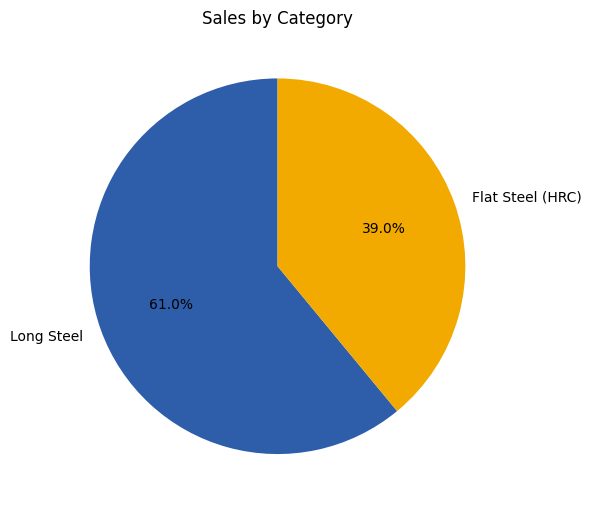

In [188]:
# Sales by Category 
cat = sales.groupby('Category')['Revenue_EGP'].sum().sort_values(ascending=False)
print("Category totals:\n", cat, "\n", (cat/cat.sum()*100).round(1))

plt.figure(figsize=(6,6))
plt.pie(cat.values, labels=cat.index, autopct='%1.1f%%', startangle=90, colors=['#2E5EAA','#F2A900'])
plt.title('Sales by Category')
plt.tight_layout()

plt.show()

Long Steel dominates the product mix, generating 61.2% of total sales compared to Flat Steel`s 38.7%.


Best month: 2023-09 2223174097
Lowest month: 2020-08 498524464


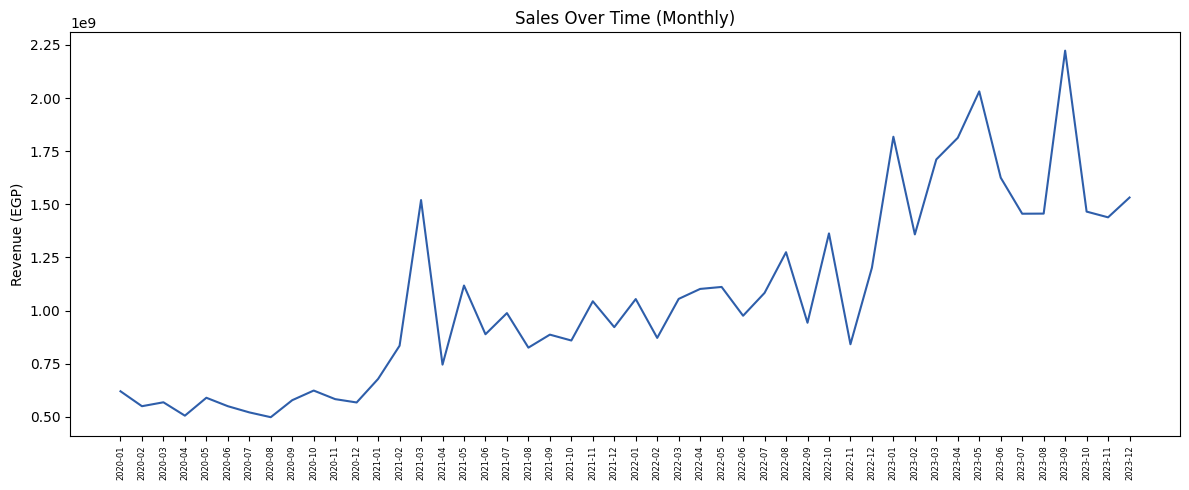

In [189]:
#  Sales Over Time 
sales['MonthPeriod'] = sales['Invoice_Date'].dt.to_period('M').astype(str)
ts = sales.groupby('MonthPeriod')['Revenue_EGP'].sum()
print("\nBest month:", ts.idxmax(), ts.max())
print("Lowest month:", ts.idxmin(), ts.min())

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, color='#2E5EAA', linewidth=1.5)
plt.xticks(rotation=90, fontsize=6)
plt.title('Sales Over Time (Monthly)')
plt.ylabel('Revenue (EGP)')
plt.tight_layout()

plt.show()


 Revenues are volatile but trend upward from 2020 to 2023; despite seasonal dips, the trajectory is positive, peaking in 2023.


Top products:
 Steel_Grade
SD390    6568699994
B500C    6540295057
B500B    6083544272
SD490    6050757277
B400B    5707594904
Name: Revenue_EGP, dtype: int64


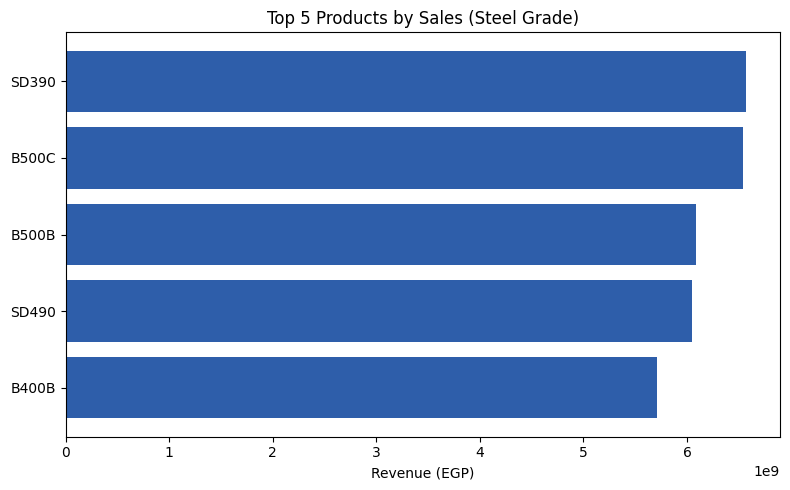

In [190]:
# Top Products
prod = sales.groupby('Steel_Grade')['Revenue_EGP'].sum().sort_values(ascending=False).head(5)
print("\nTop products:\n", prod)

plt.figure(figsize=(8,5))
plt.barh(prod.index[::-1], prod.values[::-1], color='#2E5EAA')
plt.title('Top 5 Products by Sales (Steel Grade)')
plt.xlabel('Revenue (EGP)')
plt.tight_layout()

plt.show()

SD390 is the best-selling individual product grade, closely followed by BC500.


Top regions:
 Region
Qalyubia      3986800543
Cairo         3976882276
Sharqia       3911457796
Asyut         3643530165
Suez          3491121203
Alexandria    3478545648
Gharbia       3332423423
Port Said     3291174649
Name: Revenue_EGP, dtype: int64

Top region share of total: 7.8 %


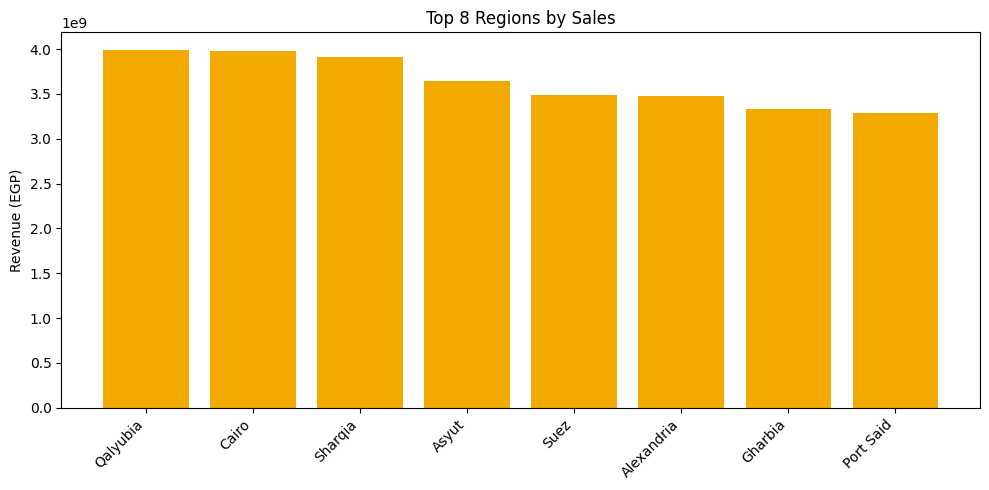

In [191]:
# Sales by Region 
reg = sales.groupby('Region')['Revenue_EGP'].sum().sort_values(ascending=False).head(8)
print("\nTop regions:\n", reg)
print("\nTop region share of total:", round(reg.iloc[0]/sales['Revenue_EGP'].sum()*100,1), "%")

plt.figure(figsize=(10,5))
plt.bar(reg.index, reg.values, color='#F2A900')
plt.xticks(rotation=45, ha='right')
plt.title('Top 8 Regions by Sales')
plt.ylabel('Revenue (EGP)')
plt.tight_layout()

plt.show()

Sales are geographically well-distributed: the top region accounts for only 7.8% of total sales, with Cario, Sharqia, and Asyut close behind - indicating no single region drives the business disproportionately.